
# DEMO INTERACTIVE DE SEUILLAGE DYNAMIQUE


Dans ce notebook vous pourrez tester des fonctions simples de traitement d'images. Cliquer sur 'run' ou tapez 'shift entrée' pour exécuter une cellule.

In [1]:
!pip install opencv-python-headless ipywidgets matplotlib --quiet

import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

## 1) Chargement d'une image et visualisation des valeurs

In [2]:
#------ Changer le nom de l'image ici !------------------
image_path = "./images/im5.png"
#image_path = "../selection/im5.png"
#--------------------------------------------------------

frame = cv2.imread(image_path)
if frame is None:
    raise ValueError("Image not found or path is incorrect")
    
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
print(gray[100:115,100:115])

[[156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 156 156 156 156 156 156 156 156 156 156 156]
 [156 156 156 156 154 156 156 156 156 156 156 156 156 156 156]
 [154 154 154 156 154 156 156 156 156 156 156 156 156 157 157]
 [154 154 154 154 154 154 154 154 154 154 154 156 156 156 156]
 [154 154 154 154 156 156 156 156 156 156 156 156 156 156 156]
 [154 153 154 154 156 156 156 156 156 156 156 156 156 156 156]]



## 2) Traitements élémentaires
conversion en niveau de gris, lissage, extraction de contours

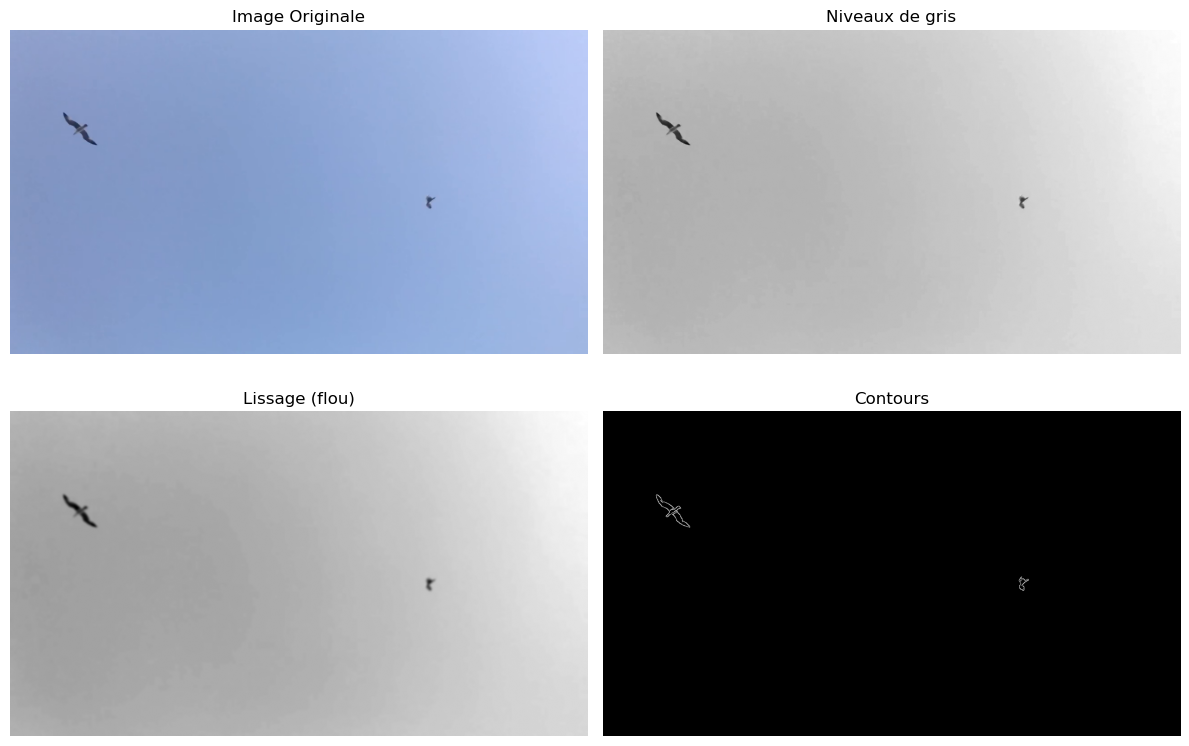

In [3]:

blur = cv2.GaussianBlur(gray, (13,13), 0)
edges = cv2.Canny(gray, 50, 150)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(frame_rgb)
plt.title("Image Originale")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Niveaux de gris")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(blur, cmap='gray')
plt.title("Lissage (flou)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(edges, cmap='gray')
plt.title("Contours")
plt.axis("off")

plt.tight_layout()
plt.show()


## 3) Segmentation basique par seuillage
Chercher le meilleur seuil !


In [4]:
def interactive_threshold(threshold=100, kernel_size=3, min_area=200):

    # Gaussian smoothing
    #blur = cv2.GaussianBlur(gray, (blur_size, blur_size), 0)

    # Inverted threshold (dark object on bright background)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY_INV)

    # Morphological opening to remove noise
    kernel = np.ones((kernel_size,kernel_size), np.uint8)
    cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Remove small components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned)
    filtered_mask = np.zeros_like(cleaned)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_area:
            filtered_mask[labels == i] = 255

    # Display results
    plt.figure(figsize=(12,6))

    plt.subplot(2,2,1)
    plt.imshow(frame_rgb)
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(gray, cmap='gray')
    plt.title("Niveaux de gris")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(mask, cmap='gray')
    plt.title("Seuillage")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(filtered_mask, cmap='gray')
    plt.title("Seuillage et filtrage")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4) Create sliders
# ------------------------------------------------------------

threshold_slider = widgets.IntSlider(
    value=100, min=0, max=255, step=1,
    description='Threshold'
)

blur_slider = widgets.IntSlider(
    value=7, min=1, max=21, step=2,
    description='Blur size'
)

area_slider = widgets.IntSlider(
    value=200, min=0, max=2000, step=50,
    description='Min area'
)

widgets.interact(
    interactive_threshold,
    threshold=threshold_slider,
    blur_size=blur_slider,
    min_area=area_slider
)

interactive(children=(IntSlider(value=100, description='Threshold', max=255), IntSlider(value=3, description='…

<function __main__.interactive_threshold(threshold=100, kernel_size=3, min_area=200)>